In [1]:
#importing the required libraries 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import missingno as msno
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, PolynomialFeatures 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_squared_error,accuracy_score,r2_score 
import warnings 
warnings.filterwarnings('ignore')


 


In [2]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv'

In [3]:
df = pd.read_csv(filepath, header = 0) 
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [4]:
#checking the dempgraphics of the data 
df.shape

(238, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      238 non-null    int64  
 1   Unnamed: 0        238 non-null    int64  
 2   Manufacturer      238 non-null    object 
 3   Category          238 non-null    int64  
 4   GPU               238 non-null    int64  
 5   OS                238 non-null    int64  
 6   CPU_core          238 non-null    int64  
 7   Screen_Size_inch  238 non-null    float64
 8   CPU_frequency     238 non-null    float64
 9   RAM_GB            238 non-null    int64  
 10  Storage_GB_SSD    238 non-null    int64  
 11  Weight_pounds     238 non-null    float64
 12  Price             238 non-null    int64  
 13  Price-binned      238 non-null    object 
 14  Screen-Full_HD    238 non-null    int64  
 15  Screen-IPS_panel  238 non-null    int64  
dtypes: float64(3), int64(11), object(2)
memory u

In [6]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Screen-Full_HD,Screen-IPS_panel
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,118.500000,118.500000,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,0.676471,0.323529
std,68.848868,68.848868,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,0.468809,0.468809
min,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,0.000000,0.000000
25%,59.250000,59.250000,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,0.000000,0.000000
50%,118.500000,118.500000,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,1.000000,0.000000
75%,177.750000,177.750000,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,1.000000,1.000000
max,237.000000,237.000000,5.000000,3.000000,2.000000,7.000000,17.300000,1.000000,16.000000,256.000000,7.938000,3810.000000,1.000000,1.000000


In [7]:
#chekcing the null present in the data 
round(df.isnull().sum()/len(df)*100,2).sort_values(ascending = False)

Unnamed: 0.1        0.0
Unnamed: 0          0.0
Manufacturer        0.0
Category            0.0
GPU                 0.0
OS                  0.0
CPU_core            0.0
Screen_Size_inch    0.0
CPU_frequency       0.0
RAM_GB              0.0
Storage_GB_SSD      0.0
Weight_pounds       0.0
Price               0.0
Price-binned        0.0
Screen-Full_HD      0.0
Screen-IPS_panel    0.0
dtype: float64

In [8]:
df.drop(['Unnamed: 0.1','Unnamed: 0'], axis = 1, inplace = True) 

<Axes: >

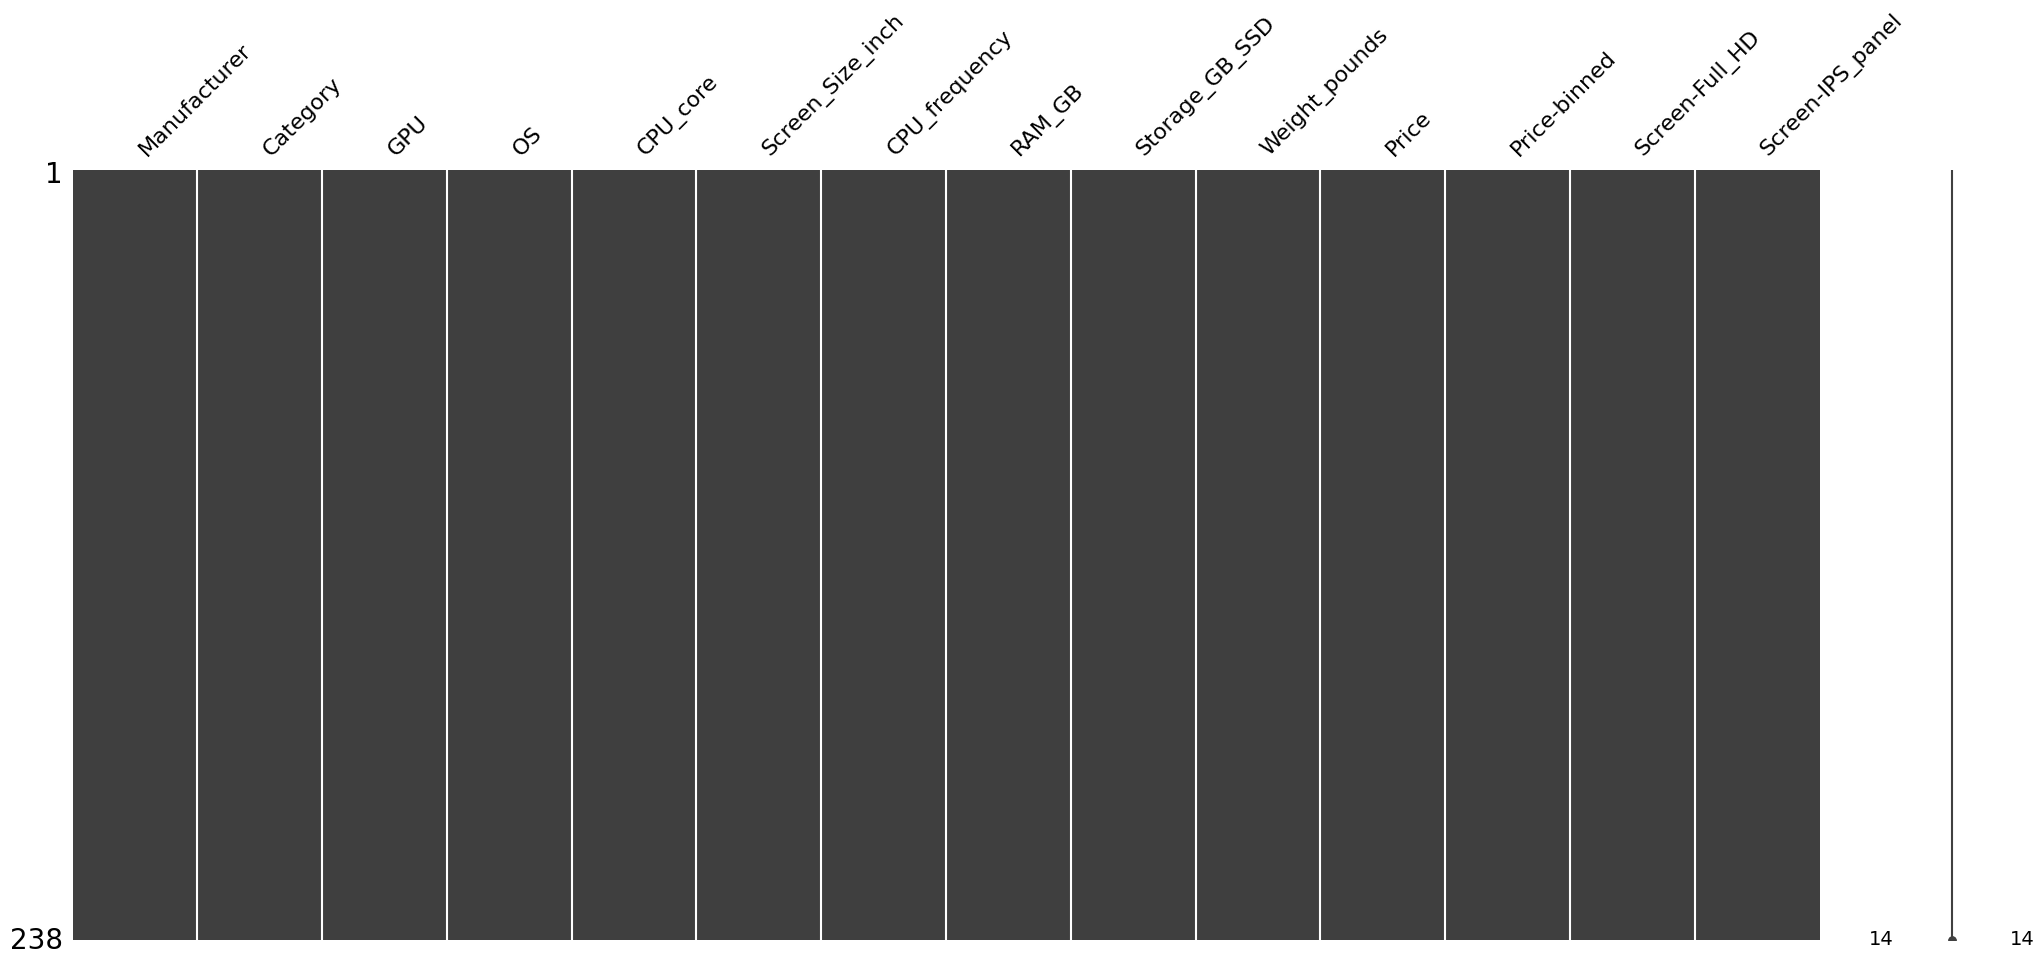

In [9]:
msno.matrix(df)

In [10]:
#seprating the catagorical and numerical for better data understanding 
num_cols = df.select_dtypes(include = ['int64', 'float64']) 
num_cols

,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Screen-Full_HD,Screen-IPS_panel
0,4,2,1,5,14.0,0.551724,8,256,3.52800,978,0,1
1,3,1,1,3,15.6,0.689655,4,256,4.85100,634,1,0
2,3,1,1,7,15.6,0.931034,8,256,4.85100,946,1,0
3,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,0,1
4,4,2,1,7,15.6,0.620690,8,256,4.21155,837,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
233,4,2,1,7,14.0,0.896552,8,256,3.74850,1891,0,1
234,3,2,1,5,13.3,0.827586,8,256,2.64600,1950,1,0
235,4,2,1,5,12.0,0.896552,8,256,2.99880,2236,0,1
236,3,3,1,5,15.6,0.862069,6,256,5.29200,883,1,0


In [11]:
cat_cols = df.select_dtypes(include = ['object']) 
cat_cols

,Manufacturer,Price-binned
0,Acer,Low
1,Dell,Low
2,Dell,Low
3,Dell,Low
4,HP,Low
...,...,...
233,Lenovo,Medium
234,Toshiba,Medium
235,Lenovo,Medium
236,Lenovo,Low


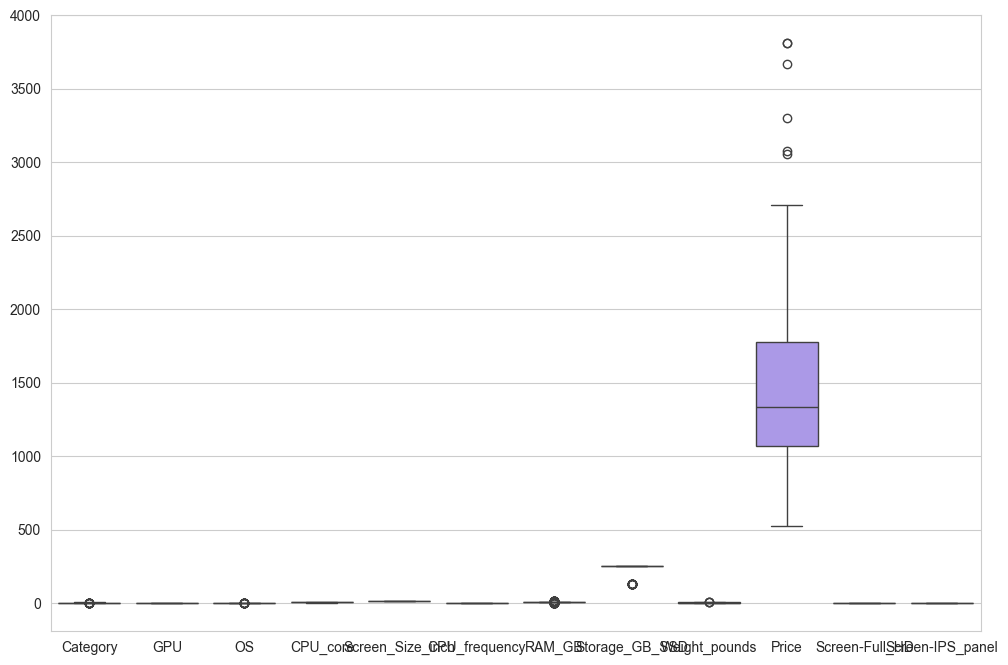

In [12]:
#checking the outliers using the boxplot 
sns.set_style('whitegrid')
plt.figure(figsize = (12,8)) 
sns.boxplot(num_cols) 
plt.show()

In [13]:
df_corr = num_cols.corr() 


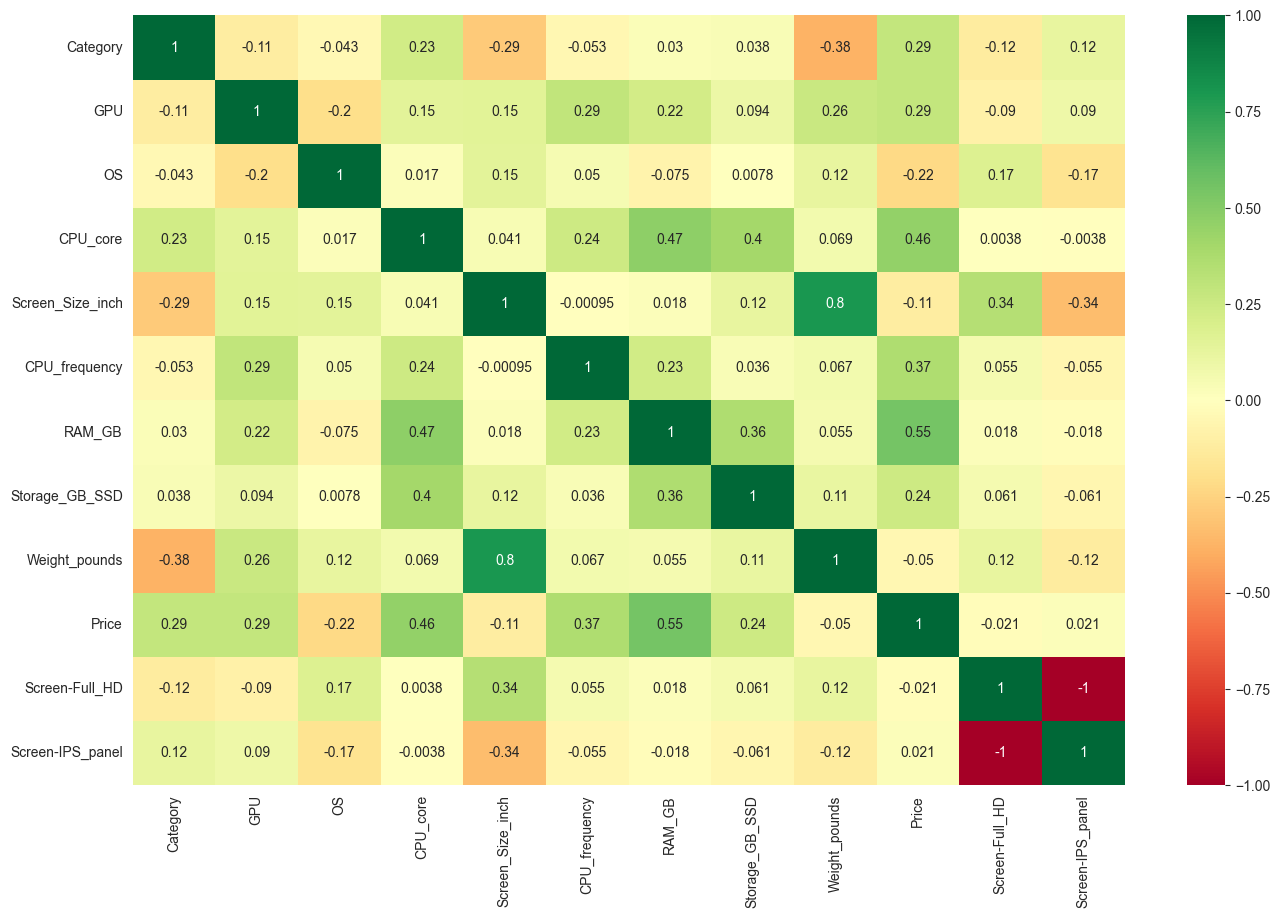

In [14]:
plt.figure(figsize = (16,10)) 
sns.heatmap(df_corr, annot = True, cmap = 'RdYlGn') 
plt.show()

In [15]:
# applying the oulier bounding 
q1 = df['Price'].quantile(0.25) 
q3 = df['Price'].quantile(0.75)

iqr = q3 - q1 

lower_bound = q1 - 1.5*iqr 
upper_bound = q3 + 1.5*iqr 

df_filtered = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]




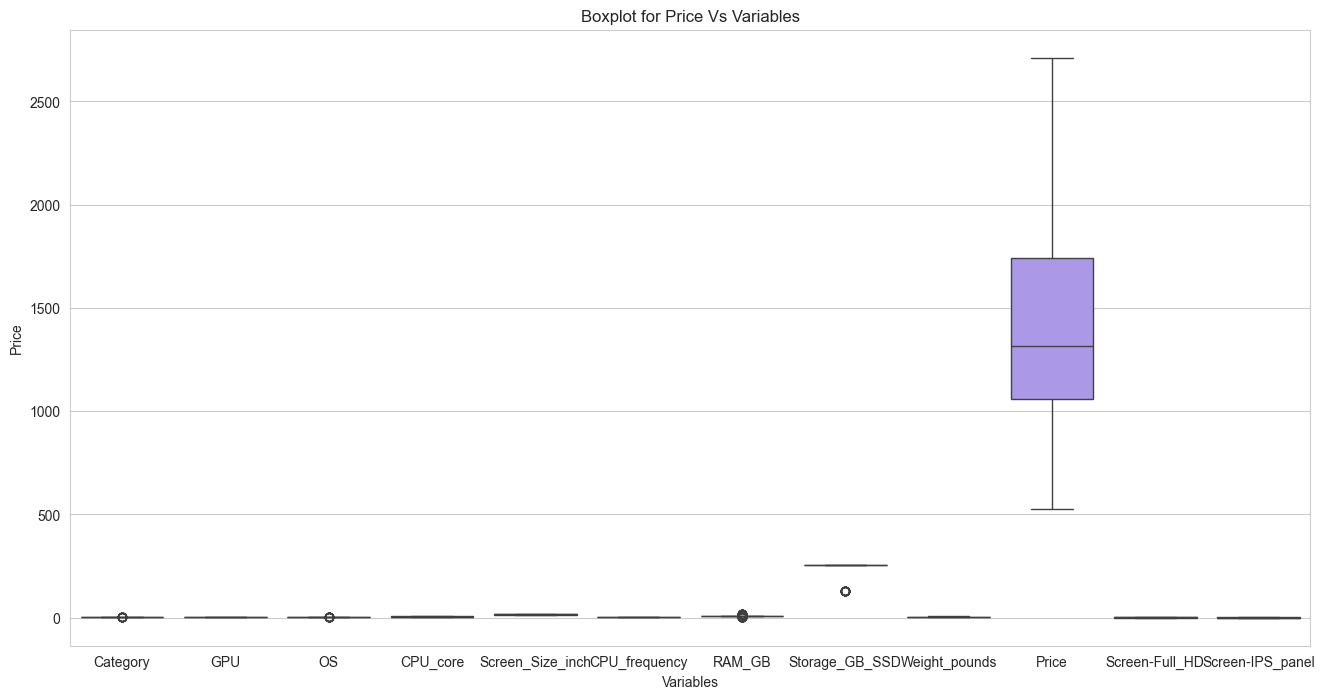

In [16]:
plt.figure(figsize = (16,8))
sns.boxplot(df_filtered)
plt.xlabel('Variables')
plt.ylabel('Price') 
plt.title('Boxplot for Price Vs Variables')
plt.show()

In [17]:
bins = [500,1000,2500, float('inf')] 
labels = ['Low', 'Medium', 'High'] 
df['binned_price'] = pd.cut(df['Price'], bins = bins, labels = labels)


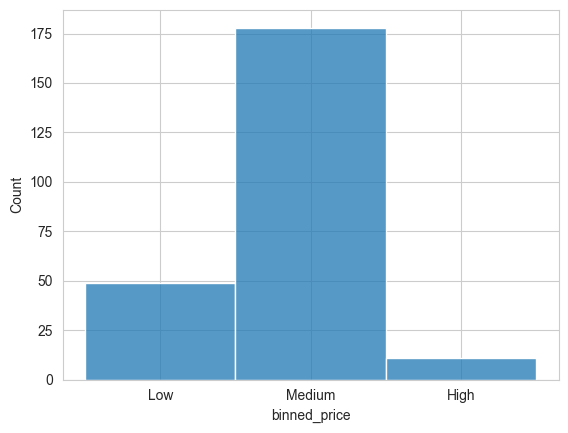

In [18]:
sns.histplot(df['binned_price'])
plt.show()

In [19]:
grouped_df = num_cols.groupby('RAM_GB')['Price'].mean()
grouped_df

RAM_GB
4      909.818182
6      829.333333
8     1508.826087
12    2125.000000
16    2377.785714
Name: Price, dtype: float64

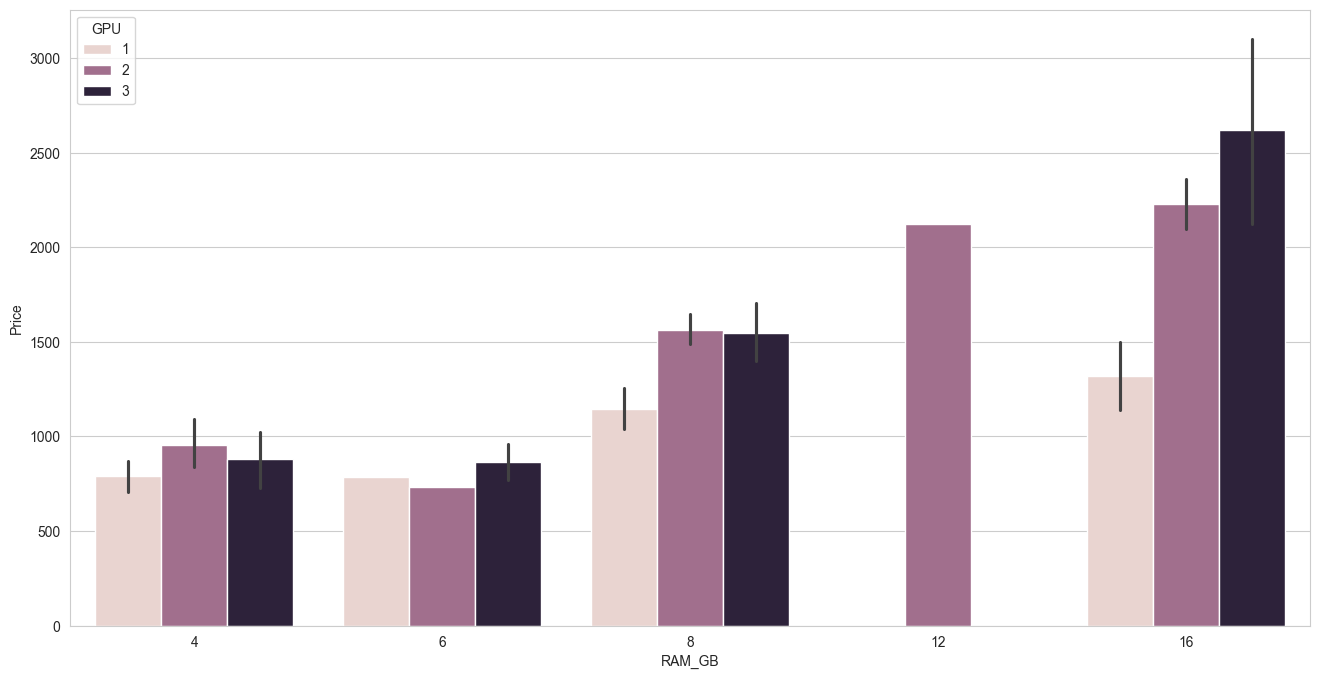

In [20]:
plt.figure(figsize = (16,8))
sns.barplot(data = df,x = 'RAM_GB', y = 'Price', hue = 'GPU')
plt.show()

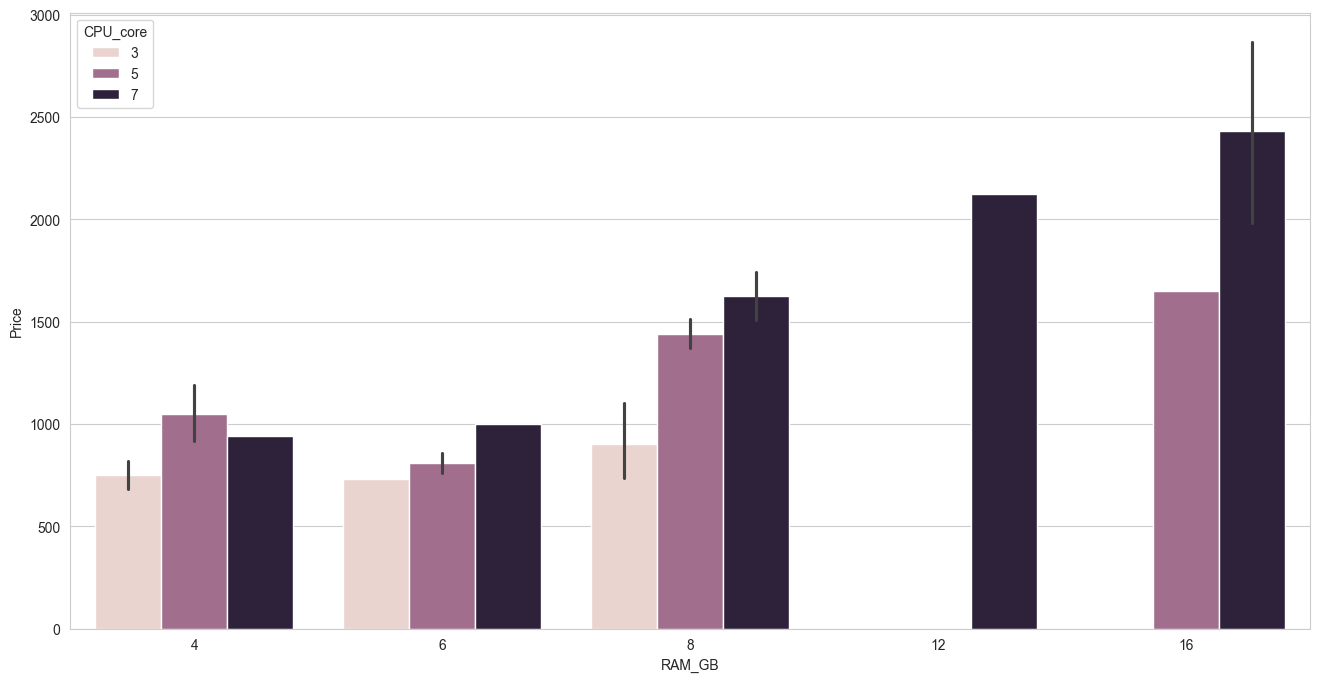

In [21]:
plt.figure(figsize = (16,8))
sns.barplot(data = df,x = 'RAM_GB', y = 'Price', hue = 'CPU_core')
plt.show()

In [22]:
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel,binned_price
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1,Low
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0,Low
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0,Low
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1,Medium
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0,Low


In [23]:
df.drop('binned_price', axis = 1, inplace = True) 


In [24]:
df.drop(['Manufacturer', 'Price-binned'], axis = 1, inplace = True) 


In [25]:
#splitting the data into X and y 
X = df.drop('Price', axis = 1) 
y = df['Price']

In [26]:
#spliting the data into train and test 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42 )
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}') 
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')  



X_train: (190, 11), X_test: (48, 11)
y_train: (190,), y_test: (48,)


In [27]:
#checking the result with the simple linear regression technique 
lr = LinearRegression() 
lr.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = lr.predict(X_test)

In [29]:
MSE = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred) 
print('MSE:',MSE)
print('R2:', R2) 

MSE: 170234.27923703546
R2: 0.26134135614626264


In [30]:
X_1 = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']]
y_1 = df['Price']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_1,y_1, test_size = .2, random_state = 42) 
print(f'X_train Size:{X_train.shape}, X_test Size:{X_test.shape}')
print(f'y_train Size:{y_train.shape}, X_test Size:{y_test.shape}')

      

X_train Size:(190, 7), X_test Size:(48, 7)
y_train Size:(190,), X_test Size:(48,)


In [32]:
lre = LinearRegression() 
lre.fit(X_train, y_train) 

LinearRegression()

In [33]:
y_pred = lre.predict(X_test) 

In [34]:
MSE = mean_squared_error(y_test, y_pred) 
R2 = r2_score(y_test, y_pred)
print('MSE:', MSE) 
print('R2:', R2)


MSE: 168575.62043820196
R2: 0.26853839463024776


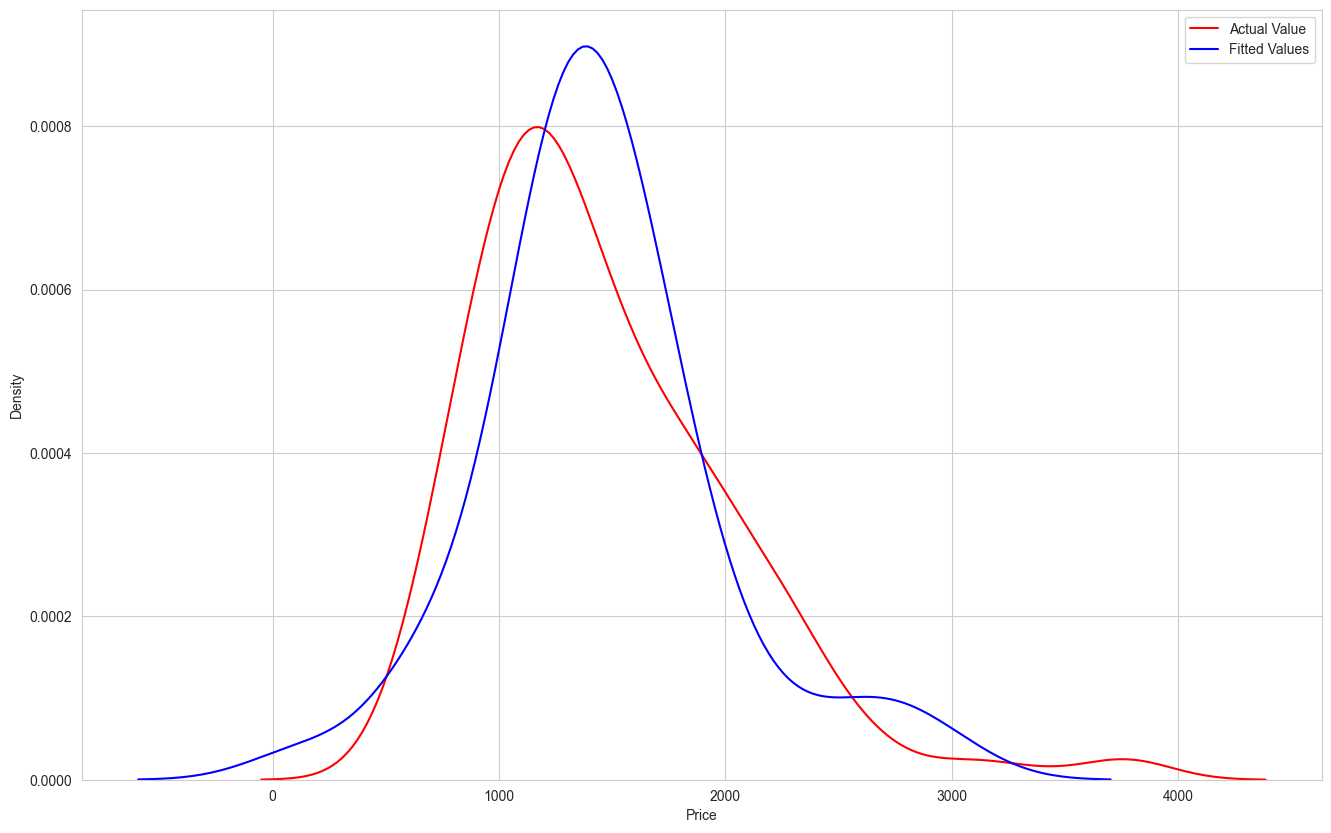

In [35]:
plt.figure(figsize=(16, 10))
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(y_pred, hist=False, color="b", label="Fitted Values" , ax=ax1)
plt.legend()
plt.show()


In [71]:
from sklearn.pipeline import Pipeline

In [72]:
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(degree = 1)), ('Model',LinearRegression())]


In [73]:
pipe = Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(degree=1)),
                ('Model', LinearRegression())])

In [74]:
pipe.fit(X_train, y_train) 

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(degree=1)),
                ('Model', LinearRegression())])

In [75]:
y_pred = pipe.predict(X_test) 


In [76]:
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
print('MSE:', mse) 
print('R2 Score:', r2)

MSE: 168575.6204382019
R2 Score: 0.2685383946302481


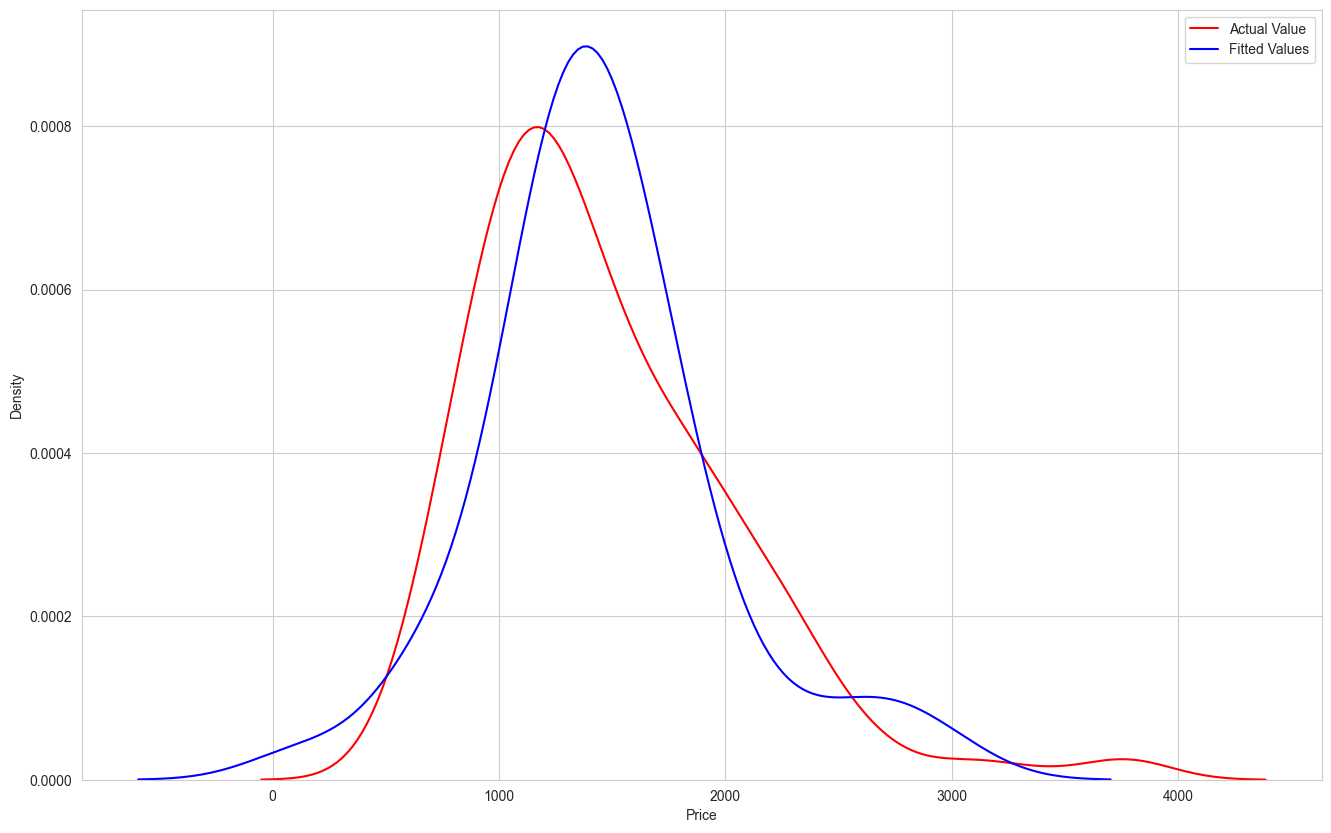

In [77]:
plt.figure(figsize=(16, 10))
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(y_pred, hist=False, color="b", label="Fitted Values" , ax=ax1)
plt.legend()
plt.show()

In [55]:
df.drop('Price-binned', axis = 1, inplace = True)

In [58]:
df = pd.concat([df, cat_cols['Price-binned']], axis = 1) 


In [82]:
ridge_pipline = Pipeline([('standard_scaler', StandardScaler()), ('ridge', Ridge(alpha = 1.0))]) 
ridge_pipline


Pipeline(steps=[('standard_scaler', StandardScaler()), ('ridge', Ridge())])

In [84]:
ridge_pipline.fit(X_train, y_train)

Pipeline(steps=[('standard_scaler', StandardScaler()), ('ridge', Ridge())])

In [87]:
y_pred = ridge_pipline.predict(X_test)

In [88]:
MSE = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
print('MSE Score: ', MSE) 
print('R2 Score: ', r2)

MSE Score:  167964.97543465203
R2 Score:  0.27118802672679043


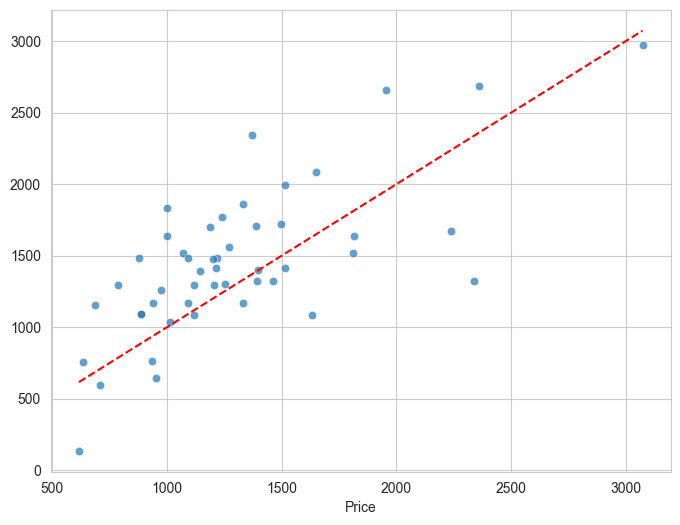

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [93]:
#Make a Lasso pipeline 
lasso_pipeline = Pipeline([('Standard Scaler', StandardScaler()),('lasso', Lasso(alpha=0.1))])
lasso_pipeline

Pipeline(steps=[('Standard Scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1))])

In [94]:
lasso_pipeline.fit(X_train, y_train) 

Pipeline(steps=[('Standard Scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1))])

In [99]:
y_pred_l = lasso_pipeline.predict(X_test) 


In [101]:
MSE = mean_squared_error(y_test, y_pred_l) 
R2 = r2_score(y_test, y_pred) 
print('RMSE: ', MSE) 
print('R2: ', R2)

RMSE:  168523.83058427463
R2:  0.2687631144894841


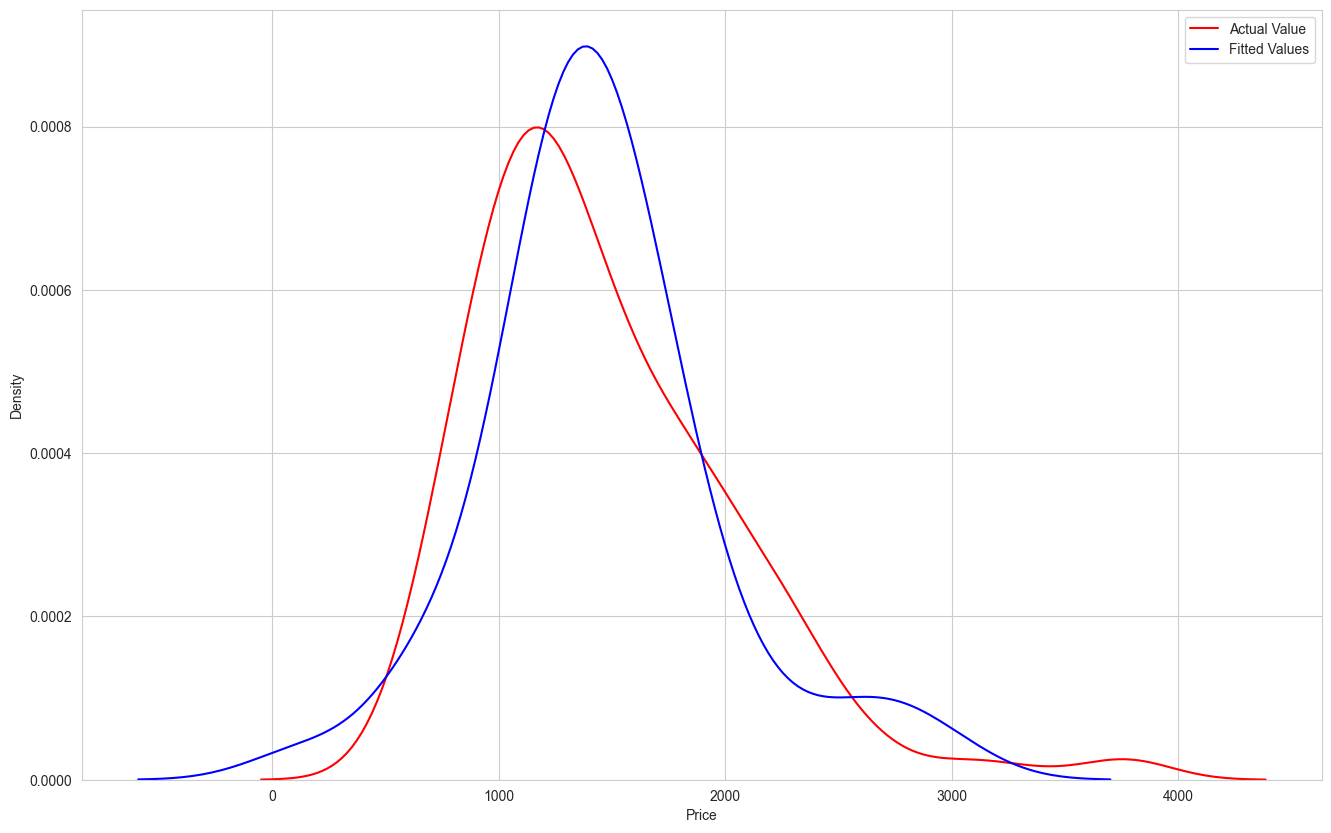

In [102]:
plt.figure(figsize=(16, 10))
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(y_pred_l, hist=False, color="b", label="Fitted Values" , ax=ax1)
plt.legend()
plt.show()